# WeatherBench 2 ERA5 탐색적 데이터 분석 (EDA)

이 노트북은 Google Cloud Storage에 공개된 **WeatherBench 2 ERA5 Zarr 데이터**를 xarray로 불러와
서울 좌표 기준으로 2020년 1년 치 데이터를 필터링하고,  
**월별 총 강수량(total precipitation)** 패턴을 바 차트로 시각화합니다.

## 사전 설치 패키지
```bash
pip install xarray zarr gcsfs fsspec matplotlib pandas numpy
```

## 데이터 출처
- WeatherBench 2 GitHub: https://github.com/google-research/weatherbench2
- GCS 버킷: `gs://weatherbench2`
- ERA5 저해상도(240×121): `gs://weatherbench2/datasets/era5/1959-2023_01_10-6h-240x121_equiangular_with_poles_conservative.zarr`

## 0. 패키지 임포트

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
%cd /content/drive/MyDrive/Colab Notebooks/AI4WeatherandClimate

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import xarray as xr
import gcsfs
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.font_manager as fm

# --- 한글 폰트 설정 (NanumGothic 직접 지정) ---
NANUM_PATH = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(NANUM_PATH)
prop = fm.FontProperties(fname=NANUM_PATH)
font_name = prop.get_name()

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지
print(f"한글 폰트 설정 완료: {font_name}")

print(f"xarray  : {xr.__version__}")
print(f"numpy   : {np.__version__}")
print(f"pandas  : {pd.__version__}")

한글 폰트 설정 완료: NanumGothic
xarray  : 2026.2.0
numpy   : 2.4.2
pandas  : 3.0.1


## 1. GCS에서 ERA5 Zarr 데이터 불러오기

WeatherBench 2는 여러 해상도의 ERA5 데이터를 GCS에 공개합니다.  
여기서는 **6시간 간격, 240×121 격자(equiangular)** 버전을 사용합니다.  
데이터 크기가 크므로 `chunks` 옵션으로 **Dask lazy loading**을 활성화합니다.

In [2]:
# GCS 파일시스템 (익명 공개 접근)
fs = gcsfs.GCSFileSystem(token='anon')

GCS_PATH = (
    "gs://weatherbench2/datasets/era5/"
    "1959-2023_01_10-6h-240x121_equiangular_with_poles_conservative.zarr"
)

store = fs.get_mapper(GCS_PATH)

ds = xr.open_zarr(store, consolidated=True, chunks={'time': 100})
print(ds)

<xarray.Dataset> Size: 2TB
Dimensions:                                           (time: 93544,
                                                       longitude: 240,
                                                       latitude: 121, level: 13)
Coordinates:
  * time                                              (time) datetime64[ns] 748kB ...
  * longitude                                         (longitude) float64 2kB ...
  * latitude                                          (latitude) float64 968B ...
  * level                                             (level) int64 104B 50 ....
Data variables: (12/62)
    10m_u_component_of_wind                           (time, longitude, latitude) float32 11GB dask.array<chunksize=(100, 240, 121), meta=np.ndarray>
    10m_v_component_of_wind                           (time, longitude, latitude) float32 11GB dask.array<chunksize=(100, 240, 121), meta=np.ndarray>
    10m_wind_speed                                    (time, longitude, latitude) flo

## 2. 데이터셋 기본 탐색 (EDA)

In [3]:
# 2-1. 차원(Dimensions) 및 좌표(Coordinates) 확인
print("=== 차원 ===")
for dim, size in ds.dims.items():
    print(f"  {dim}: {size}")

print("\n=== 좌표 ===")
for coord in ds.coords:
    print(f"  {coord}: {ds.coords[coord].values[:3]} ... shape={ds.coords[coord].shape}")

=== 차원 ===
  time: 93544
  longitude: 240
  latitude: 121
  level: 13

=== 좌표 ===
  latitude: [-90.  -88.5 -87. ] ... shape=(121,)
  level: [ 50 100 150] ... shape=(13,)
  longitude: [0.  1.5 3. ] ... shape=(240,)
  time: ['1959-01-01T00:00:00.000000000' '1959-01-01T06:00:00.000000000'
 '1959-01-01T12:00:00.000000000'] ... shape=(93544,)


In [4]:
# 2-2. 변수(Variables) 목록
print("=== 변수 목록 ===")
for var in sorted(ds.data_vars):
    v = ds[var]
    units = v.attrs.get('units', 'N/A')
    long_name = v.attrs.get('long_name', '')
    print(f"  {var:<45} units={units:<15} {long_name}")

=== 변수 목록 ===
  10m_u_component_of_wind                       units=m s**-1         10 metre U wind component
  10m_v_component_of_wind                       units=m s**-1         10 metre V wind component
  10m_wind_speed                                units=N/A             
  2m_dewpoint_temperature                       units=K               2 metre dewpoint temperature
  2m_temperature                                units=K               2 metre temperature
  above_ground                                  units=N/A             
  ageostrophic_wind_speed                       units=N/A             
  angle_of_sub_gridscale_orography              units=radians         Angle of sub-gridscale orography
  anisotropy_of_sub_gridscale_orography         units=~               Anisotropy of sub-gridscale orography
  boundary_layer_height                         units=m               Boundary layer height
  divergence                                    units=N/A             
  eddy_kinetic_ene

In [5]:
# 2-3. 시간 범위 확인
time_vals = ds.time.values
print(f"시간 시작 : {pd.Timestamp(time_vals[0])}")
print(f"시간 끝   : {pd.Timestamp(time_vals[-1])}")
print(f"총 타임스텝: {len(time_vals):,}  (6시간 간격)")

시간 시작 : 1959-01-01 00:00:00
시간 끝   : 2023-01-10 18:00:00
총 타임스텝: 93,544  (6시간 간격)


In [6]:
# 2-4. 위/경도 격자 범위 확인
lats = ds.latitude.values
lons = ds.longitude.values
print(f"위도  : {lats.min():.2f}° ~ {lats.max():.2f}°  (총 {len(lats)} 격자점, 간격 {np.diff(lats).mean():.2f}°)")
print(f"경도  : {lons.min():.2f}° ~ {lons.max():.2f}°  (총 {len(lons)} 격자점, 간격 {np.diff(lons).mean():.2f}°)")

위도  : -90.00° ~ 90.00°  (총 121 격자점, 간격 1.50°)
경도  : 0.00° ~ 358.50°  (총 240 격자점, 간격 1.50°)


In [7]:
# 2-5. total_precipitation_6hr 변수 상세 확인
VAR = 'total_precipitation_6hr'

if VAR in ds:
    tp = ds[VAR]
    print(tp)
    print("\n속성(attributes):")
    for k, v in tp.attrs.items():
        print(f"  {k}: {v}")
else:
    print(f"'{VAR}' 변수가 없습니다. 사용 가능한 강수 관련 변수:")
    for var in ds.data_vars:
        if 'precip' in var.lower() or 'precipitation' in var.lower():
            print(f"  {var}")

<xarray.DataArray 'total_precipitation_6hr' (time: 93544, longitude: 240,
                                             latitude: 121)> Size: 11GB
dask.array<open_dataset-total_precipitation_6hr, shape=(93544, 240, 121), dtype=float32, chunksize=(100, 240, 121), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 748kB 1959-01-01 ... 2023-01-10T18:00:00
  * longitude  (longitude) float64 2kB 0.0 1.5 3.0 4.5 ... 355.5 357.0 358.5
  * latitude   (latitude) float64 968B -90.0 -88.5 -87.0 ... 87.0 88.5 90.0
Attributes:
    long_name:   Total precipitation
    short_name:  tp
    units:       m

속성(attributes):
  long_name: Total precipitation
  short_name: tp
  units: m


## 3. 서울 좌표 기준 2020년 데이터 필터링

| 항목 | 값 |
|------|----|
| 위도 | 37.56°N |
| 경도 | 126.97°E |
| 기간 | 2020-01-01 ~ 2020-12-31 |

`method='nearest'`로 격자점 중 서울에 가장 가까운 격자점을 선택합니다.

In [8]:
# 서울 좌표 (WGS84)
SEOUL_LAT = 37.56
SEOUL_LON = 126.97

# 2020년 시간 범위 슬라이스 + 서울 가장 가까운 격자점 선택
tp_seoul_2020 = (
    ds[VAR]
    .sel(time=slice('2020-01-01', '2020-12-31T23:59:59'))
    .sel(latitude=SEOUL_LAT, longitude=SEOUL_LON, method='nearest')
)

# 실제로 선택된 격자점 좌표 확인
sel_lat = float(tp_seoul_2020.latitude)
sel_lon = float(tp_seoul_2020.longitude)
print(f"요청 좌표 : 위도 {SEOUL_LAT}°N, 경도 {SEOUL_LON}°E")
print(f"선택 격자 : 위도 {sel_lat:.2f}°N, 경도 {sel_lon:.2f}°E")
print(f"\n타임스텝 수: {len(tp_seoul_2020.time)} (6시간 × 366일 = 1464)")
print(tp_seoul_2020)

요청 좌표 : 위도 37.56°N, 경도 126.97°E
선택 격자 : 위도 37.50°N, 경도 127.50°E

타임스텝 수: 1464 (6시간 × 366일 = 1464)
<xarray.DataArray 'total_precipitation_6hr' (time: 1464)> Size: 6kB
dask.array<getitem, shape=(1464,), dtype=float32, chunksize=(100,), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 12kB 2020-01-01 ... 2020-12-31T18:00:00
    latitude   float64 8B 37.5
    longitude  float64 8B 127.5
Attributes:
    long_name:   Total precipitation
    short_name:  tp
    units:       m


In [9]:
# Dask 계산 실행 (compute)
print("데이터 다운로드 중... (GCS → 메모리)")
tp_seoul_2020 = tp_seoul_2020.compute()
print("완료!")

# pandas Series로 변환 (분석 편의)
ts = tp_seoul_2020.to_series()
ts.index = pd.to_datetime(ts.index)
print(f"\n기초 통계 (단위: {tp_seoul_2020.attrs.get('units', 'm')})")
print(ts.describe())

데이터 다운로드 중... (GCS → 메모리)
완료!

기초 통계 (단위: m)
count    1.464000e+03
mean     1.028992e-03
std      3.555613e-03
min     -2.235175e-08
25%      1.117587e-08
50%      9.332338e-06
75%      2.482498e-04
max      4.488967e-02
Name: total_precipitation_6hr, dtype: float64


## 4. 월별 총 강수량 계산

In [10]:
# 6시간 누적 강수량을 월별로 합산하고 단위를 m → mm로 변환
monthly_precip_mm = ts.resample('ME').sum() * 1000  # 1 m = 1000 mm
monthly_precip_mm.index = monthly_precip_mm.index.strftime('%b')  # Jan, Feb, ...

print("월별 총 강수량 (mm):")
for month, val in monthly_precip_mm.items():
    bar = '█' * int(val / 10)
    print(f"  {month:>3}  {val:7.1f} mm  {bar}")

월별 총 강수량 (mm):
  Jan     84.8 mm  ████████
  Feb     64.3 mm  ██████
  Mar     25.9 mm  ██
  Apr     30.9 mm  ███
  May    103.7 mm  ██████████
  Jun    119.8 mm  ███████████
  Jul    287.4 mm  ████████████████████████████
  Aug    501.9 mm  ██████████████████████████████████████████████████
  Sep    203.8 mm  ████████████████████
  Oct      7.1 mm  
  Nov     67.3 mm  ██████
  Dec      9.5 mm  


## 5. 월별 총 강수량 바 차트 시각화

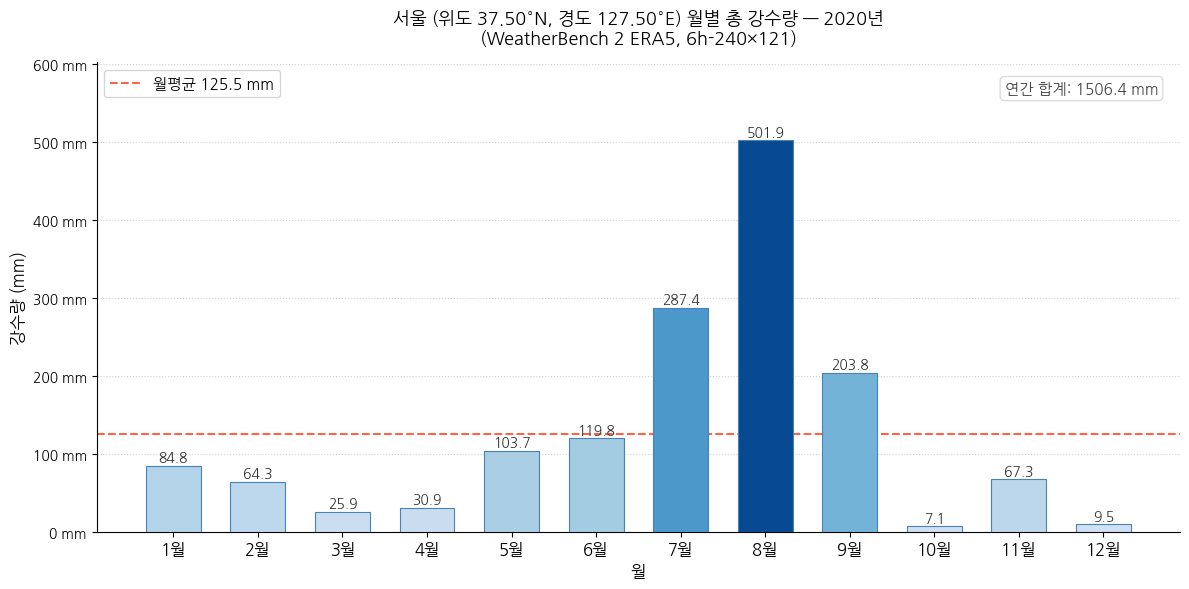

그래프 저장 완료: seoul_monthly_precipitation_2020.png


In [11]:
MONTHS_KR = ['1월','2월','3월','4월','5월','6월',
             '7월','8월','9월','10월','11월','12월']

values = monthly_precip_mm.values
x = np.arange(len(MONTHS_KR))

# 색상: 강수량 기준 그라디언트 (낮으면 하늘색, 높으면 진파랑)
norm = plt.Normalize(vmin=values.min(), vmax=values.max())
cmap = plt.cm.Blues
colors = [cmap(norm(v) * 0.7 + 0.2) for v in values]  # 너무 연한 색 방지

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(x, values, color=colors, edgecolor='steelblue',
              linewidth=0.8, width=0.65, zorder=3)

# 각 막대 위에 수치 표시
for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f'{val:.1f}',
        ha='center', va='bottom', fontsize=10, color='#333333'
    )

# 연평균 강수량 수평 기준선
annual_mean = values.mean()
ax.axhline(annual_mean, color='tomato', linestyle='--', linewidth=1.5,
           label=f'월평균 {annual_mean:.1f} mm')

# 축 및 레이블
ax.set_xticks(x)
ax.set_xticklabels(MONTHS_KR, fontsize=12)
ax.set_ylabel('강수량 (mm)', fontsize=12)
ax.set_xlabel('월', fontsize=12)
ax.set_title(
    f'서울 (위도 {sel_lat:.2f}°N, 경도 {sel_lon:.2f}°E) 월별 총 강수량 — 2020년\n'
    f'(WeatherBench 2 ERA5, 6h-240×121)',
    fontsize=13, pad=14
)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f mm'))
ax.set_ylim(0, values.max() * 1.2)
ax.grid(axis='y', linestyle=':', alpha=0.6, zorder=0)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=11)

# 연간 합계 텍스트
annual_total = values.sum()
ax.text(0.98, 0.96, f'연간 합계: {annual_total:.1f} mm',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=11, color='#444444',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='lightgray', alpha=0.8))

plt.tight_layout()
plt.savefig('seoul_monthly_precipitation_2020.png', dpi=150, bbox_inches='tight')
plt.show()
print("그래프 저장 완료: seoul_monthly_precipitation_2020.png")

## 6. 6시간 강수량 시계열 플롯 (추가 EDA)

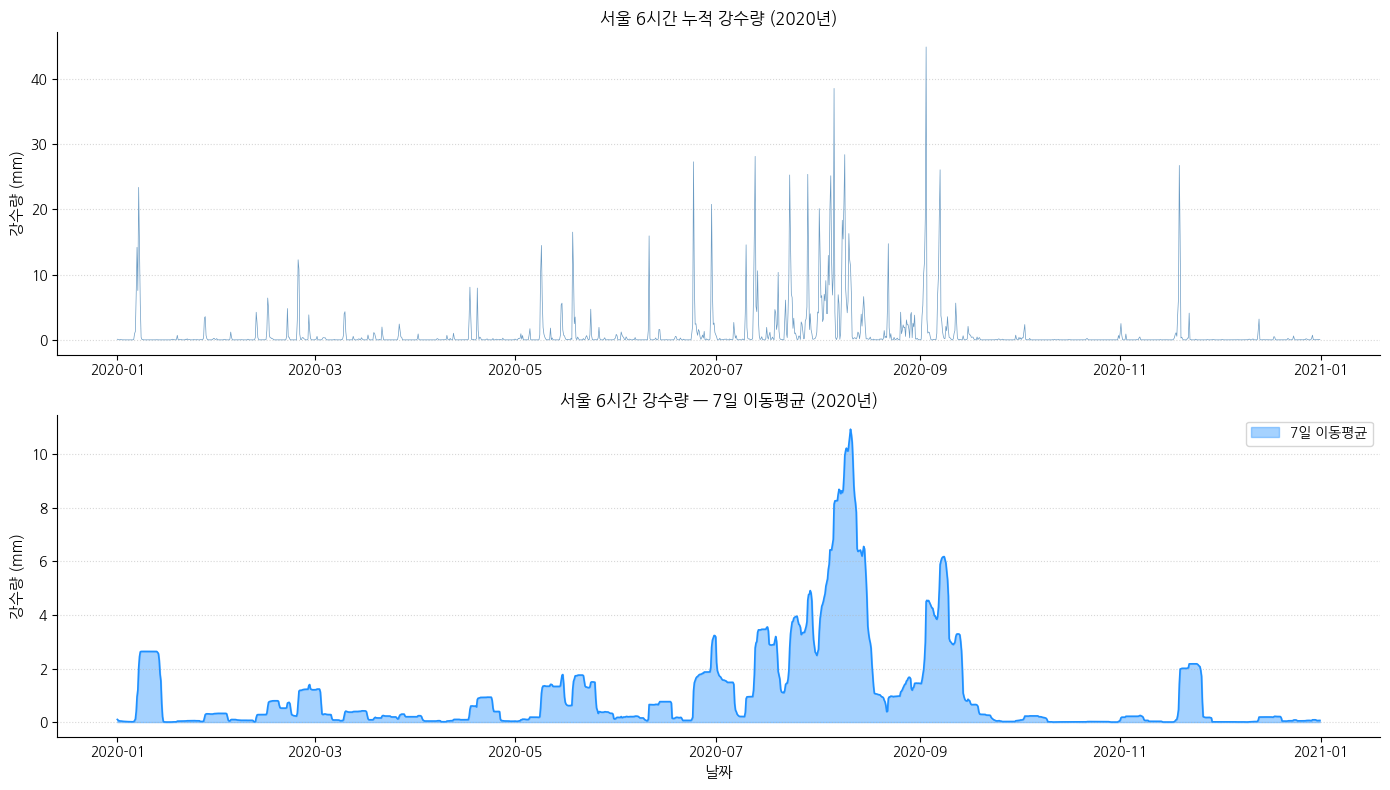

그래프 저장 완료: seoul_timeseries_precipitation_2020.png


In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

# 상단: 6시간 강수량 시계열
ts_mm = ts * 1000  # m → mm
axes[0].plot(ts_mm.index, ts_mm.values, color='steelblue', linewidth=0.5, alpha=0.8)
axes[0].set_title('서울 6시간 누적 강수량 (2020년)', fontsize=12)
axes[0].set_ylabel('강수량 (mm)', fontsize=11)
axes[0].grid(axis='y', linestyle=':', alpha=0.5)
axes[0].spines[['top', 'right']].set_visible(False)

# 하단: 7일 이동평균
rolling_mm = ts_mm.rolling('7D').mean()
axes[1].fill_between(rolling_mm.index, rolling_mm.values,
                     alpha=0.4, color='dodgerblue', label='7일 이동평균')
axes[1].plot(rolling_mm.index, rolling_mm.values,
             color='dodgerblue', linewidth=1.2)
axes[1].set_title('서울 6시간 강수량 — 7일 이동평균 (2020년)', fontsize=12)
axes[1].set_ylabel('강수량 (mm)', fontsize=11)
axes[1].set_xlabel('날짜', fontsize=11)
axes[1].grid(axis='y', linestyle=':', alpha=0.5)
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('seoul_timeseries_precipitation_2020.png', dpi=150, bbox_inches='tight')
plt.show()
print("그래프 저장 완료: seoul_timeseries_precipitation_2020.png")

## 7. 요약 통계

In [13]:
summary = pd.DataFrame({
    '월': MONTHS_KR,
    '총 강수량 (mm)': monthly_precip_mm.values.round(1),
    '비율 (%)': (monthly_precip_mm.values / monthly_precip_mm.values.sum() * 100).round(1)
})

summary_total = pd.DataFrame([{
    '월': '합계/평균',
    '총 강수량 (mm)': round(monthly_precip_mm.values.sum(), 1),
    '비율 (%)': 100.0
}])

summary = pd.concat([summary, summary_total], ignore_index=True)
print(summary.to_string(index=False))

    월  총 강수량 (mm)     비율 (%)
   1월   84.800003   5.600000
   2월   64.300003   4.300000
   3월   25.900000   1.700000
   4월   30.900000   2.100000
   5월  103.699997   6.900000
   6월  119.800003   8.000000
   7월  287.399994  19.100000
   8월  501.899994  33.299999
   9월  203.800003  13.500000
  10월    7.100000   0.500000
  11월   67.300003   4.500000
  12월    9.500000   0.600000
합계/평균 1506.400024 100.000000
